In [1]:
import numerical_solver as ns

constants for numerical solver 

In [5]:
# size of domain
Lx = 10.0
Ly = 10.0

# number of grid points
nx = 101
ny = 101

# smooth random boundary parameters (SINN-style)
n_modes = 4         # low-frequency modes -> smoother fields
amp_scale = 1.0     # overall boundary amplitude
seed = 0            # change for a different sample

# Laplace solver parameters
tol = 1e-7
max_iter = 50000
w = 1.8             # SOR relaxation (1<w<2), 1.7-1.95 usually fine

# crop margin (optional)
x_margin = 1.5
y_margin = 1.5

# number of plots (snapshots); Laplace gives 1 snapshot
num_plots = 2


numerical solver

[laplace] it=00001, max_update=1.780e+00
[laplace] converged: it=812, max_update=9.929e-08


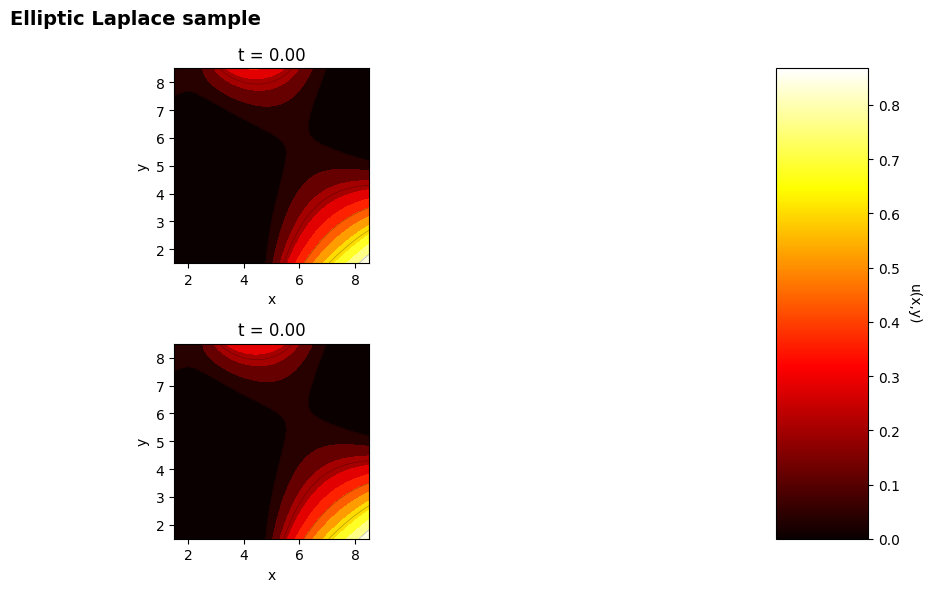

In [6]:
num_solver = ns.LaplaceDirichlet2D(Lx, Ly, nx, ny)

# Generate ONE smooth Laplace sample (T has length 1, snapshots has length 1)
T, snapshots, g_boundary = num_solver.generate_one_sample(
    n_modes=n_modes,
    amp_scale=amp_scale,
    seed=seed,
    tol=tol,
    max_iter=max_iter,
    w=w,
    verbose=True
)

# Optionally crop (keeps the same interface as your previous notebook)
X, Y, U = ns.crop_data(num_solver.X, num_solver.Y, snapshots, x_margin, y_margin)

# Visualise
vmax = max([s.max() for s in U])
ns.create_visualisation(X, Y, U, T, num_plots, vmax)


I have X, Y which are the coordinates of the grid. I have U which has a 2D array for each time step containing the scalar value of the feature and T which has the time passed for each value in the array.

sinn solver

In [7]:
import pickle
import os

# Get the current working directory
save_path = os.path.join(os.getcwd(), 'numerical_data.pkl')

# Save variables to a pickle file
data = {'X': X, 'Y': Y, 'U': U, 'T': T}
with open(save_path, 'wb') as f:
    pickle.dump(data, f)

print(f"Variables saved to {save_path}")

Variables saved to c:\Users\darsh\Documents\fyp\myfyp\advection_diffusion\time_in_encoders_only\numerical_data.pkl
